# Saddle Point Navigation with Newton Method

Multi-robot cluster navigation to saddle points in scalar fields using distributed sensing and Newton's method for critical point location.

## Scalar Field Navigation: Saddle Point Finding via Newton's Method

Navigate a 4-robot square formation to critical points in scalar fields using distributed gradient and Hessian estimation.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import combinations


class SaddlePointNavigator:
    """Navigate 4-robot square formation to critical points in scalar fields.
    
    Uses distributed gradient and Hessian estimation via planar fitting.
    Supports optional rotation control to align formation with Newton direction.
    """
    
    def __init__(self, robot_distance=0.3, step_size=0.01, n_iterations=100, 
                 rotation_gain=0.0):
        self.robot_distance = robot_distance
        self.step_size = step_size
        self.n_iterations = n_iterations
        self.rotation_gain = rotation_gain  # 0 = no rotation, >0 = enabled
        self.use_rotation = rotation_gain > 0
        self.history = {
            'centroids': [],
            'gradients': [],
            'hessians': [],
            'rotations': [],
            'rotation_errors': [],
            'best_k_history': []  # Track which k was chosen each iteration
        }
        
    def scalar_field(self, x, y):
        """Bimodal scalar field: z = log(exp(G1) + exp(G2))"""
        gaussian1 = -((x + 2)**2 + y**2) / 2
        gaussian2 = -((x - 2)**2 + y**2) / 2
        max_exp = np.maximum(gaussian1, gaussian2)
        return max_exp + np.log(np.exp(gaussian1 - max_exp) + np.exp(gaussian2 - max_exp))
    
    def initialize_robots(self, centroid, rotation_angle=None):
        """Create 4 robots in square pattern around centroid."""
        if rotation_angle is None:
            rotation_angle = np.random.uniform(0, 2*np.pi)
        
        angles = np.array([0, np.pi/2, np.pi, 3*np.pi/2]) + rotation_angle
        robots = np.array([[centroid[0] + self.robot_distance * np.cos(a),
                            centroid[1] + self.robot_distance * np.sin(a)] 
                           for a in angles])
        return robots, rotation_angle
    
    def estimate_gradient_from_plane(self, points_3d):
        """Fit plane to 3 points [x, y, z]; return gradient [dz/dx, dz/dy]."""
        A = np.column_stack([points_3d[:, 0], points_3d[:, 1], np.ones(3)])
        coeffs = np.linalg.lstsq(A, points_3d[:, 2], rcond=None)[0]
        return coeffs[0], coeffs[1]
    
    def estimate_hessian(self, centroids, gradients):
        """Fit planes to gradient components; return Hessian matrix."""
        dz_dx = gradients[:, 0]
        dz_dy = gradients[:, 1]
        
        A = np.column_stack([centroids[:, 0], centroids[:, 1], np.ones(4)])
        
        try:
            coeffs_dx = np.linalg.lstsq(A, dz_dx, rcond=None)[0]
            d2z_dx2, d2z_dxdy_from_dx = coeffs_dx[0], coeffs_dx[1]
        except np.linalg.LinAlgError:
            d2z_dx2, d2z_dxdy_from_dx = 0, 0
        
        try:
            coeffs_dy = np.linalg.lstsq(A, dz_dy, rcond=None)[0]
            d2z_dxdy_from_dy, d2z_dy2 = coeffs_dy[0], coeffs_dy[1]
        except np.linalg.LinAlgError:
            d2z_dxdy_from_dy, d2z_dy2 = 0, 0
        
        return np.array([[d2z_dx2, d2z_dxdy_from_dx],
                        [d2z_dxdy_from_dy, d2z_dy2]])
    
    def compute_newton_step(self, gradient, hessian):
        """Compute Newton step: -H^(-1) * grad."""
        try:
            det = np.linalg.det(hessian)
            if abs(det) > 1e-10:
                step = -np.linalg.solve(hessian, gradient)
            else:
                step = -np.linalg.pinv(hessian) @ gradient
        except np.linalg.LinAlgError:
            step = -gradient / (np.linalg.norm(gradient) + 1e-10)
        
        # Limit step size
        if np.linalg.norm(step) > 1.0:
            step = step / np.linalg.norm(step)
        
        return step
    
    def compute_rotation_error(self, hessian, current_rotation, gradient):
        """Align formation with Newton step direction.
        
        ORIGINAL LOGIC (unmodified): Pick whichever k minimizes error each iteration.
        """
        step = self.compute_newton_step(gradient, hessian)
        
        if np.linalg.norm(step) > 1e-10:
            newton_angle = np.arctan2(step[1], step[0])
        else:
            eigenvalues, eigenvectors = np.linalg.eigh(hessian)
            principal_direction = eigenvectors[:, np.argmax(np.abs(eigenvalues))]
            newton_angle = np.arctan2(principal_direction[1], principal_direction[0])
        
        # Find best alignment (4 discrete choices in square formation)
        errors = []
        for k in range(4):
            target = newton_angle - k * np.pi/2
            error = target - current_rotation
            error = np.arctan2(np.sin(error), np.cos(error))
            errors.append(error)
        
        best_idx = np.argmin(np.abs(errors))
        
        # Store which k was chosen so we can diagnose the jumps
        self.history['best_k_history'].append(best_idx)
        
        return errors[best_idx]
    
    def navigate(self, start_centroid, initial_rotation=None):
        """Main navigation loop."""
        centroid = np.array(start_centroid, dtype=float)
        
        if initial_rotation is None:
            current_rotation = np.random.uniform(0, 2*np.pi)
        else:
            current_rotation = initial_rotation
        
        self.initial_centroid = centroid.copy()
        self.initial_robots, _ = self.initialize_robots(centroid, current_rotation)
        self.initial_rotation = current_rotation
        
        for iteration in range(self.n_iterations):
            robots, _ = self.initialize_robots(centroid, current_rotation)
            z_values = np.array([self.scalar_field(r[0], r[1]) for r in robots])
            points_3d = np.column_stack([robots, z_values])
            
            # Get 4 gradients from all C(4,3)=4 triangular subsets
            gradients = []
            centroids = []
            for combo in combinations(range(4), 3):
                grad = self.estimate_gradient_from_plane(points_3d[list(combo)])
                gradients.append(grad)
                centroid_3 = np.mean(robots[list(combo)], axis=0)
                centroids.append(centroid_3)
            
            gradients = np.array(gradients)
            centroids = np.array(centroids)
            hessian = self.estimate_hessian(centroids, gradients)
            avg_gradient = np.mean(gradients, axis=0)
            
            # Store history
            self.history['centroids'].append(centroid.copy())
            self.history['gradients'].append(avg_gradient.copy())
            self.history['hessians'].append(hessian.copy())
            self.history['rotations'].append(current_rotation)
            
            # Compute motion
            direction = self.compute_newton_step(avg_gradient, hessian)
            
            if self.use_rotation:
                rotation_error = self.compute_rotation_error(hessian, current_rotation, avg_gradient)
                self.history['rotation_errors'].append(rotation_error)
                current_rotation += self.rotation_gain * rotation_error
                current_rotation = current_rotation % (2 * np.pi)
            
            centroid = centroid + self.step_size * direction
        
        self.final_centroid = centroid
        self.final_robots, _ = self.initialize_robots(centroid, current_rotation)
        self.final_rotation = current_rotation
        return centroid
    
    def save_estimates(self, filename='gradient_hessian_estimates.txt'):
        """Save convergence history to file."""
        try:
            with open(filename, 'w') as f:
                f.write("GRADIENT AND HESSIAN ESTIMATES\n")
                f.write("=" * 50 + "\n\n")
                
                for i in range(len(self.history['gradients'])):
                    eigenvals, _ = np.linalg.eigh(self.history['hessians'][i])
                    f.write(f"Iteration {i+1}:\n")
                    f.write(f"  Centroid: {self.history['centroids'][i]}\n")
                    f.write(f"  Gradient: {self.history['gradients'][i]}\n")
                    f.write(f"  Gradient mag: {np.linalg.norm(self.history['gradients'][i]):.6f}\n")
                    f.write(f"  Hessian evals: {eigenvals}\n")
                    if self.use_rotation:
                        f.write(f"  Rotation: {np.degrees(self.history['rotations'][i]):.2f}°\n")
                    f.write("\n")
                
                f.write("=" * 50 + "\n")
                f.write(f"Final centroid: {self.final_centroid}\n")
                f.write(f"Distance to origin: {np.linalg.norm(self.final_centroid):.6f}\n")
            print(f"Saved to {filename}")
        except OSError as e:
            print(f"Could not save: {e}")
    
    def visualize(self):
        """Visualize navigation trajectory and convergence metrics."""
        x = np.linspace(-3, 3, 100)
        y = np.linspace(-3, 3, 100)
        X, Y = np.meshgrid(x, y)
        Z = self.scalar_field(X, Y)
        
        fig = plt.figure(figsize=(15, 10))
        
        # Contour with trajectory
        ax1 = fig.add_subplot(221)
        ax1.contour(X, Y, Z, levels=20, cmap='viridis')
        trajectory = np.array(self.history['centroids'])
        ax1.plot(trajectory[:, 0], trajectory[:, 1], 'r-', linewidth=2, label='Trajectory')
        ax1.plot(*self.initial_centroid, 'b*', markersize=15, label='Start')
        ax1.plot(*self.final_centroid, 'r*', markersize=15, label='End')
        ax1.plot(0, 0, 'kx', markersize=15, linewidth=3, label='True saddle')
        ax1.set_xlabel('X'); ax1.set_ylabel('Y')
        ax1.set_title('Trajectory on Scalar Field')
        ax1.legend(); ax1.grid(True, alpha=0.3); ax1.set_aspect('equal')
        
        # 3D surface
        ax2 = fig.add_subplot(222, projection='3d')
        ax2.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
        z_traj = np.array([self.scalar_field(c[0], c[1]) for c in trajectory])
        ax2.plot(trajectory[:, 0], trajectory[:, 1], z_traj, 'r-', linewidth=3)
        ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
        ax2.set_title('3D Surface with Trajectory')
        
        # Gradient magnitude
        ax3 = fig.add_subplot(223)
        grad_mags = [np.linalg.norm(g) for g in self.history['gradients']]
        ax3.semilogy(grad_mags, 'b-', linewidth=2)
        ax3.set_xlabel('Iteration'); ax3.set_ylabel('Gradient Magnitude')
        ax3.set_title('Convergence (log scale)')
        ax3.grid(True, alpha=0.3)
        
        # Distance and Hessian eigenvalues
        ax4 = fig.add_subplot(224)
        distances = [np.linalg.norm(c) for c in self.history['centroids']]
        ax4.plot(distances, 'g-', linewidth=2, label='Distance to origin')
        
        # Plot Hessian eigenvalues
        eigenvals = []
        for H in self.history['hessians']:
            evals, _ = np.linalg.eigh(H)
            eigenvals.append(evals)
        eigenvals = np.array(eigenvals)
        ax4_2 = ax4.twinx()
        ax4_2.plot(eigenvals[:, 0], 'c--', alpha=0.7, label='λ₁')
        ax4_2.plot(eigenvals[:, 1], 'y--', alpha=0.7, label='λ₂')
        ax4.set_xlabel('Iteration')
        ax4.set_ylabel('Distance', color='g')
        ax4_2.set_ylabel('Eigenvalues')
        ax4.set_title('Distance and Hessian Eigenvalues')
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\nNavigation Summary:")
        print(f"Start: {self.initial_centroid}, End: {self.final_centroid}")
        print(f"Distance to saddle: {np.linalg.norm(self.final_centroid):.4f}")
        print(f"Final gradient magnitude: {grad_mags[-1]:.6f}")
        final_evals, _ = np.linalg.eigh(self.history['hessians'][-1])
        print(f"Final Hessian eigenvalues: {final_evals}")
    
    def visualize_rotation(self):
        """Separate visualization for rotation control diagnostics."""
        if not self.use_rotation:
            print("Rotation control disabled; nothing to visualize.")
            return
        
        # Figure 1: Formation rotation angle
        fig1, ax = plt.subplots(figsize=(12, 5))
        ax.plot(np.degrees(self.history['rotations']), 'purple', linewidth=2)
        ax.set_xlabel('Iteration', fontsize=12)
        ax.set_ylabel('Formation Rotation (°)', fontsize=12)
        ax.set_title('Formation Orientation Over Time', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Figure 2: Rotation alignment error
        fig2, ax = plt.subplots(figsize=(12, 5))
        ax.plot(np.degrees(self.history['rotation_errors']), 'orange', linewidth=2)
        ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
        ax.set_xlabel('Iteration', fontsize=12)
        ax.set_ylabel('Alignment Error (°)', fontsize=12)
        ax.set_title('Rotation Error (Alignment Mismatch)', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Figure 3: Which k was chosen
        fig3, ax = plt.subplots(figsize=(12, 5))
        colors = ['C0', 'C1', 'C2', 'C3']
        for k in range(4):
            mask = np.array(self.history['best_k_history']) == k
            if np.any(mask):
                indices = np.where(mask)[0]
                ax.scatter(indices, [k]*len(indices), c=colors[k], s=30, alpha=0.7, label=f'k={k}')
        ax.set_ylim(-0.5, 3.5)
        ax.set_xlabel('Iteration', fontsize=12)
        ax.set_ylabel('Chosen Alignment (k)', fontsize=12)
        ax.set_title('4-Way Alignment Selection', fontsize=13, fontweight='bold')
        ax.set_yticks([0, 1, 2, 3])
        ax.legend(ncol=4, loc='upper right', fontsize=11)
        ax.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()
        
        # Figure 4: Error with transition markers
        fig4, ax = plt.subplots(figsize=(12, 5))
        k_diff = np.diff([self.history['best_k_history'][0]] + self.history['best_k_history'])
        transitions = np.where(k_diff != 0)[0]
        
        ax.plot(np.degrees(self.history['rotation_errors']), 'orange', linewidth=2)
        ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
        
        if len(transitions) > 0:
            for t in transitions:
                ax.axvline(t, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
            ax.text(0.02, 0.98, f'{len(transitions)} transitions', 
                   transform=ax.transAxes, va='top', fontsize=11,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        ax.set_xlabel('Iteration', fontsize=12)
        ax.set_ylabel('Alignment Error (°)', fontsize=12)
        ax.set_title('Error with k-Transition Points (red lines)', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


In [10]:
%matplotlib inline

Example 1: Without rotation control
Saved to estimates_no_rotation.txt


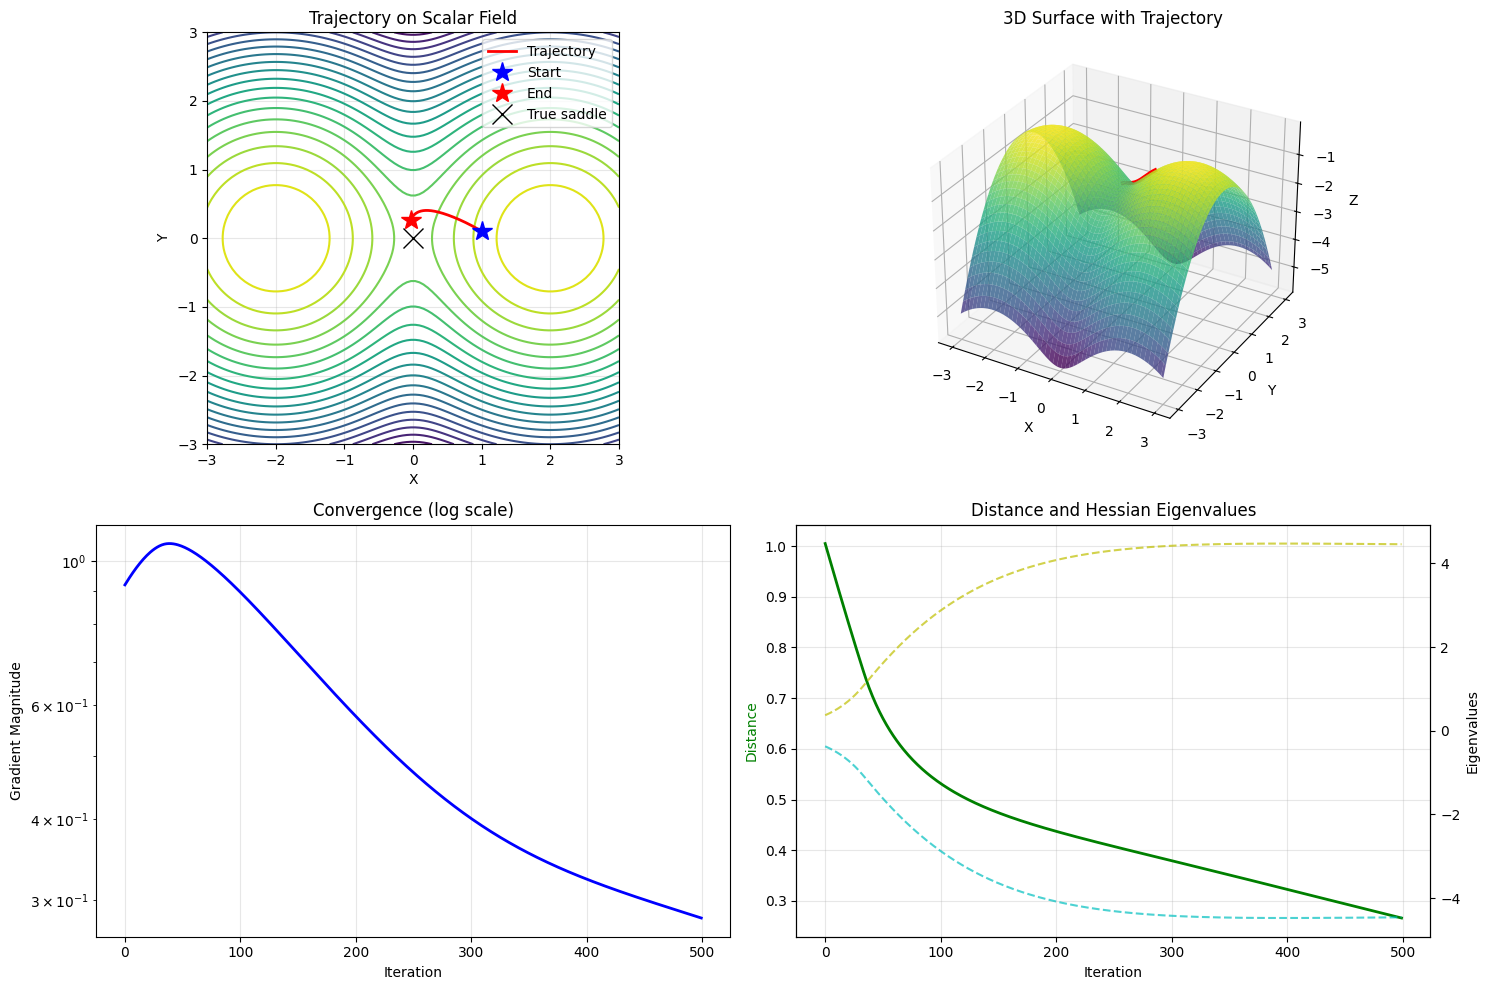


Navigation Summary:
Start: [1.  0.1], End: [-0.03300445  0.26376541]
Distance to saddle: 0.2658
Final gradient magnitude: 0.281427
Final Hessian eigenvalues: [-4.456324  4.456324]

Example 2: With rotation control (kr=0.1)

Saved to estimates_with_rotation.txt


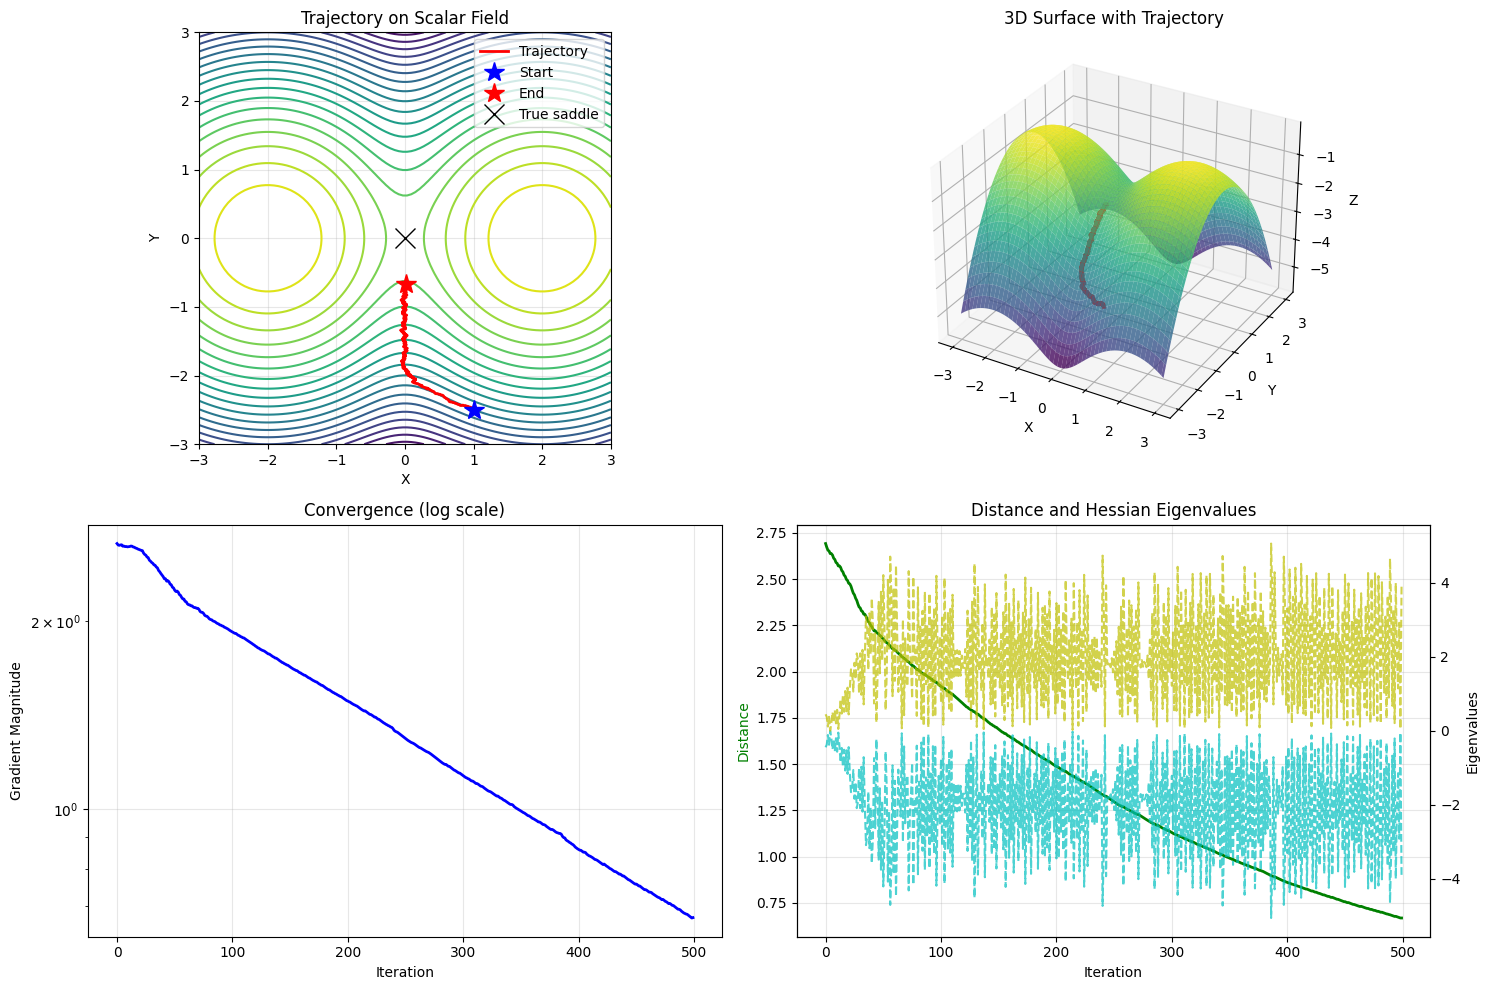


Navigation Summary:
Start: [ 1.  -2.5], End: [ 0.02066346 -0.66589868]
Distance to saddle: 0.6662
Final gradient magnitude: 0.669349
Final Hessian eigenvalues: [-3.95458767  3.95458767]


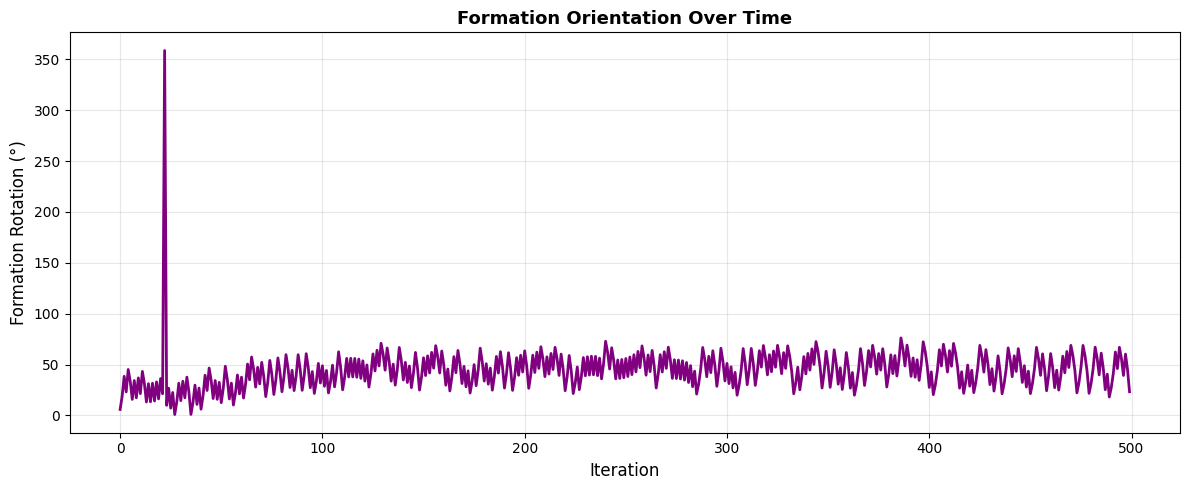

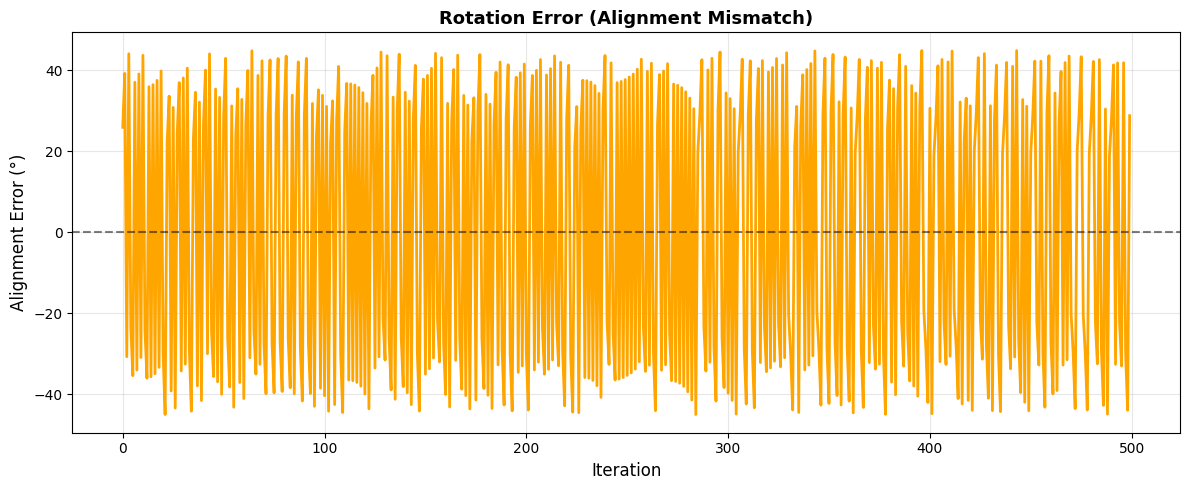

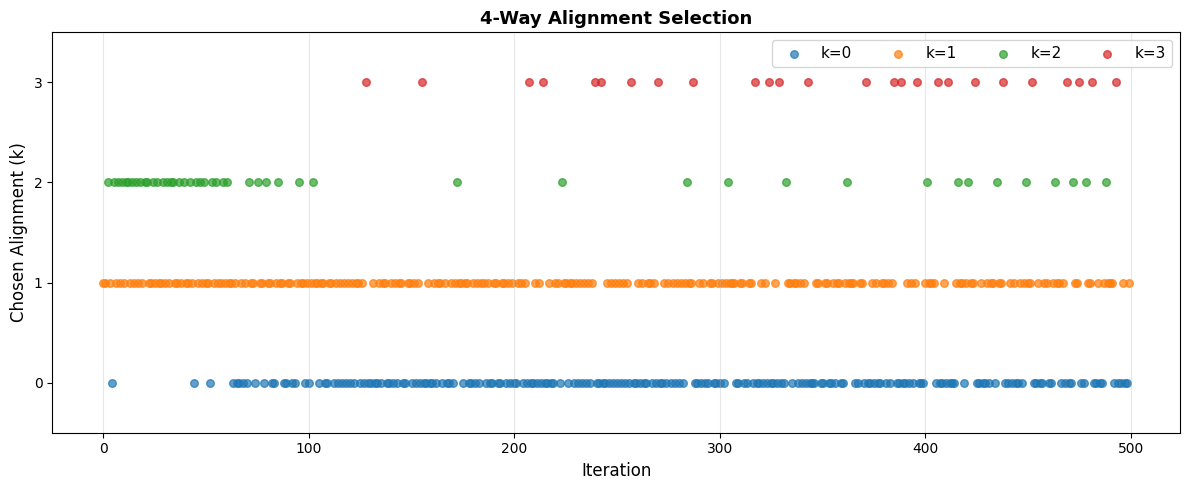

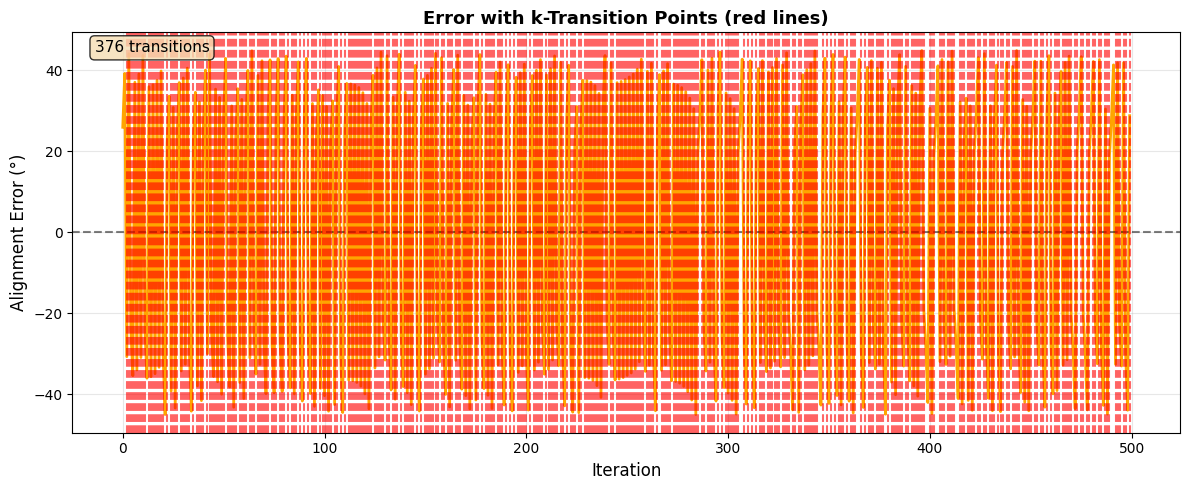

In [11]:
# Example 1: Without rotation control
print("="*60)
print("Example 1: Without rotation control")
print("="*60)
navigator_no_rot = SaddlePointNavigator(
    robot_distance=0.3,
    step_size=0.01,
    n_iterations=500,
    rotation_gain=0.0  # Disabled
)
final_pos = navigator_no_rot.navigate([1.0, 0.1])
navigator_no_rot.save_estimates('estimates_no_rotation.txt')
navigator_no_rot.visualize()

print("\n" + "="*60)
print("Example 2: With rotation control (kr=0.1)")
print("="*60 + "\n")

# Example 2: With rotation control
navigator_with_rot = SaddlePointNavigator(
    robot_distance=0.25,
    step_size=0.02,
    n_iterations=500,
    rotation_gain=0.5  # Enabled with kr=0.01
)
final_pos = navigator_with_rot.navigate([1.0, -2.5])
navigator_with_rot.save_estimates('estimates_with_rotation.txt')
navigator_with_rot.visualize()
navigator_with_rot.visualize_rotation()

## Theory: Gradient and Hessian Estimation from Robot Clusters

### Gradient Estimation
Given 4 robots measuring scalar field values at positions $(x_i, y_i) \to z_i$, we fit planes to all ${4 \choose 3} = 4$ triangular subsets to estimate gradients at each subset's centroid:
$$\nabla z_j = [a_j, b_j]^T \text{ from } z = ax + by + c$$

The 4 gradients at 4 distinct locations enable Hessian reconstruction via second-order fitting.

### Hessian Reconstruction
Fit planes to the spatial variation of gradient components:
$$\frac{\partial z}{\partial x} = \alpha_x x + \beta_x y + \gamma_x, \quad \frac{\partial z}{\partial y} = \alpha_y x + \beta_y y + \gamma_y$$

The Hessian matrix is:
$$\mathbf{H} = \begin{bmatrix} \alpha_x & \beta_x \\ \alpha_y & \beta_y \end{bmatrix}$$

### Newton's Method for Critical Points
The Newton step toward the critical point is:
$$\Delta \mathbf{p} = -\mathbf{H}^{-1} \nabla z$$

We apply proportional control to reach this critical point: $\dot{\mathbf{p}} = k \cdot \Delta \mathbf{p}$

### Formation Rotation Control (Optional)
Aligning the square formation with the Newton direction improves estimates. Target orientation:
$$\theta_{\text{desired}} = \arctan2(\Delta p_y, \Delta p_x) + \frac{k\pi}{2}$$
with proportional update: $\dot{\theta} = k_r(\theta_{\text{desired}} - \theta)$